In [1]:
import os
os.environ['XLA_FLAGS'] = os.environ.get('XLA_FLAGS', '') + ' --xla_gpu_autotune_level=0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'          # don't grab all VRAM upfront
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.80'          # leave 20% free for cuBLAS workspace

import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-U",
    "jax[cuda12]",
    "equinox>=0.11", "optax>=0.2",
    "numpy", "pandas", "scikit-learn", "scipy", "matplotlib", "tqdm"],
    check=True)
print("Done installing packages.")


Kernel Python: /usr/bin/python3
Done installing packages.


# 03 — Diffusion Model Training

Load the clustered data, build the `DiffusionTransformer1D`, train with `Trainer`, and inspect generated samples mid-run.

In [27]:
import importlib
import importlib.util
import inspect
import json
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path


def clone_repo(repo_url: str, target_dir: Path) -> None:
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip() or 'git clone failed')


def download_repo_archive(archive_url: str, runtime_dir: Path, repo_dir: Path, extract_dir: Path, archive_path: Path) -> None:
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def _is_colab() -> bool:
    return importlib.util.find_spec('google.colab') is not None


def find_or_bootstrap_repo_root() -> Path:
    candidates = [
        Path('/home/nicola/Desktop/Supsi/tesina'),
        Path.cwd().resolve(),
        Path('/content/tesina'),
        Path('/tmp/vscode-colab/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    if _is_colab():
        runtime_dir = Path('/content')
        repo_dir = runtime_dir / 'tesina'
    else:
        runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
        repo_dir = runtime_dir / 'tesina'

    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)

    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)

    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir

    raise RuntimeError('Could not locate or bootstrap the tesina project root from the current notebook kernel.')


REPO_ROOT = find_or_bootstrap_repo_root()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx

# Reload src modules so that edits to source files take effect without a kernel restart
import src.data.loader, src.data.dataset, src.models.transformer1d, src.models.diffusion, src.training.train
importlib.reload(src.data.loader)
importlib.reload(src.data.dataset)
importlib.reload(src.models.transformer1d)
importlib.reload(src.models.diffusion)
importlib.reload(src.training.train)

try:
    import src.runtime_paths
    importlib.reload(src.runtime_paths)
    from src.runtime_paths import prepare_artifact_dirs
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class _ArtifactPaths:
        repo_root: Path
        data_dir: Path
        checkpoints_dir: Path
        results_root: Path
        run_results_dir: Path

    def prepare_artifact_dirs(repo_root: str | Path, experiment: str | None = None) -> _ArtifactPaths:
        root = Path(repo_root).expanduser().resolve()
        data_dir = root / 'data'
        checkpoints_dir = root / 'checkpoints'
        results_root = root / 'results'
        run_results_dir = results_root if not experiment else results_root / experiment
        for directory in (checkpoints_dir, results_root, run_results_dir):
            directory.mkdir(parents=True, exist_ok=True)
        return _ArtifactPaths(
            repo_root=root,
            data_dir=data_dir,
            checkpoints_dir=checkpoints_dir,
            results_root=results_root,
            run_results_dir=run_results_dir,
        )

from src.data.loader import load_raw, compute_stats, normalize
from src.data.dataset import make_windows, train_val_split, numpy_dataloader
from src.models.transformer1d import DiffusionTransformer1D
from src.models.diffusion import DiffusionProcess
from src.training.train import Trainer

if 'balance_condition_cols' not in inspect.signature(numpy_dataloader).parameters:
    class _BalancedInfiniteLoader:
        def __init__(
            self,
            xs: np.ndarray,
            cs: np.ndarray,
            batch_size: int,
            balance_condition_cols: tuple[int, ...],
            shuffle: bool,
            rng: np.random.Generator,
        ):
            grouped_indices = {}
            for idx, row in enumerate(cs):
                key = tuple(int(row[col]) for col in balance_condition_cols)
                grouped_indices.setdefault(key, []).append(idx)

            self.group_keys = sorted(grouped_indices)
            self.grouped_indices = {
                key: np.asarray(indices, dtype=np.int32)
                for key, indices in grouped_indices.items()
            }
            self.batch_size = batch_size
            self.shuffle = shuffle
            self.rng = rng
            self.xs = xs
            self.cs = cs
            self.epoch_len = max(1, len(xs) // batch_size)

        def __iter__(self):
            return self

        def __next__(self):
            n_groups = len(self.group_keys)
            base = self.batch_size // n_groups
            remainder = self.batch_size % n_groups
            batch_indices = []

            for group_idx, key in enumerate(self.group_keys):
                n_take = base + int(group_idx < remainder)
                if n_take == 0:
                    continue
                pool = self.grouped_indices[key]
                sampled = self.rng.choice(pool, size=n_take, replace=len(pool) < n_take)
                batch_indices.append(sampled)

            batch_indices = np.concatenate(batch_indices, axis=0)
            if self.shuffle:
                self.rng.shuffle(batch_indices)
            return self.xs[batch_indices], self.cs[batch_indices]

    _base_numpy_dataloader = numpy_dataloader

    def numpy_dataloader(
        xs: np.ndarray,
        cs: np.ndarray,
        batch_size: int,
        shuffle: bool = True,
        balance_condition_cols: tuple[int, ...] | None = None,
        rng: int | np.random.Generator = 0,
    ):
        if isinstance(rng, int):
            rng = np.random.default_rng(rng)
        if balance_condition_cols is not None:
            return _BalancedInfiniteLoader(
                xs,
                cs,
                batch_size,
                tuple(balance_condition_cols),
                shuffle,
                rng,
            )
        return _base_numpy_dataloader(xs, cs, batch_size=batch_size, shuffle=shuffle, rng=rng)

ARTIFACTS = prepare_artifact_dirs(REPO_ROOT, experiment='diffusion')
DATA_DIR = ARTIFACTS.data_dir
CHECKPOINT_DIR = ARTIFACTS.checkpoints_dir
RESULTS_DIR = ARTIFACTS.run_results_dir

plt.rcParams['figure.dpi'] = 110
print('Project root :', REPO_ROOT)
print('Checkpoints  :', CHECKPOINT_DIR)
print('Results dir  :', RESULTS_DIR)
print('JAX devices  :', jax.devices())

# ── Training budget ──────────────────────────────────────────────────────────
# BATCH_SIZE increased from 64 → 256 to better utilise T4 VRAM (16 GB).
# LR scaled by sqrt(256/64) = 2× following the sqrt scaling rule for Adam.
# Early stopping (patience=20 epochs) will halt training if val loss plateaus.
QUICK_RUN  = False
N_EPOCHS   = 5    if QUICK_RUN else 200
BATCH_SIZE = 256
LR         = 2e-3
WARMUP_STEPS   = 300   if QUICK_RUN else 2000
GUIDANCE_SCALE = 1.5

CHECKPOINT_NAME = 'best_model.pkl'

Project root : /content/tesina
Checkpoints  : /content/tesina/checkpoints
Results dir  : /content/tesina/results/diffusion
JAX devices  : [CudaDevice(id=0)]


In [22]:
# ── Artifact policy ───────────────────────────────────────────────────────────
# Checkpoints and generated outputs are always written inside the repository
# working tree used by the current kernel. On Colab this means /content/tesina,
# not Google Drive. Copy artifacts out manually if you need to persist them
# after the runtime is recycled.
print('Artifact root  :', REPO_ROOT)
print('Checkpoint dir :', CHECKPOINT_DIR)
print('Results dir    :', RESULTS_DIR)

Artifact root  : /content/tesina
Checkpoint dir : /content/tesina/checkpoints
Results dir    : /content/tesina/results/diffusion


## 1. Load & prepare data

In [23]:
df = load_raw(DATA_DIR / 'power.pk')

clusters_df = pd.read_csv(DATA_DIR / 'clusters.csv')
cluster_labels = clusters_df['cluster_id'].values            # (N,)
N_CLUSTERS = int(cluster_labels.max()) + 1

print(f'{df.shape[1]} meters, {N_CLUSTERS} clusters')
print(f'Cluster sizes: { {c: (cluster_labels==c).sum() for c in range(N_CLUSTERS)} }')

# Use the DatetimeIndex already present in power.pk
timestamps = df.index if isinstance(df.index, pd.DatetimeIndex) else None

stats = compute_stats(df, cluster_labels)
df_norm = normalize(df, stats, cluster_labels)


321 meters, 3 clusters
Cluster sizes: {0: np.int64(183), 1: np.int64(34), 2: np.int64(104)}


In [24]:
xs, cs, mid = make_windows(df_norm, cluster_labels, timestamps)
print(f'Windows: xs={xs.shape}  cs={cs.shape}  mid={mid.shape}')

x_train, c_train, x_val, c_val = train_val_split(xs, cs, mid, n_meters=df.shape[1])
print(f'Train: {x_train.shape[0]}  Val: {x_val.shape[0]}')

# ── Per-cluster window count ──
print('\nWindows per cluster (train):')
for cid in range(N_CLUSTERS):
    n_tr = (c_train[:, 0] == cid).sum()
    n_va = (c_val[:,   0] == cid).sum()
    wd   = (c_train[:, 1] == 0).sum()
    we   = (c_train[:, 1] == 1).sum()
    print(f'  Cluster {cid}: train={n_tr:6d}  val={n_va:5d}  (all: weekday={wd}, weekend={we})')

# ── Sanity: check z-score normalisation per cluster ──
print('\nNormalised value stats per cluster (train, should be ~mean=0, std=1):')
for cid in range(N_CLUSTERS):
    mask = c_train[:, 0] == cid
    vals = x_train[mask].ravel()
    print(f'  Cluster {cid}: mean={vals.mean():+.3f}  std={vals.std():.3f}  '
          f'min={vals.min():.3f}  max={vals.max():.3f}')


Windows: xs=(351816, 24)  cs=(351816, 4)  mid=(351816,)
Train: 299208  Val: 52608

Windows per cluster (train):
  Cluster 0: train=169880  val=30688  (all: weekday=213759, weekend=85449)
  Cluster 1: train= 31784  val= 5480  (all: weekday=213759, weekend=85449)
  Cluster 2: train= 97544  val=16440  (all: weekday=213759, weekend=85449)

Normalised value stats per cluster (train, should be ~mean=0, std=1):
  Cluster 0: mean=+0.025  std=1.077  min=-0.306  max=26.476
  Cluster 1: mean=+0.031  std=1.080  min=-0.212  max=17.986
  Cluster 2: mean=+0.024  std=1.066  min=-0.449  max=11.326


## 2. Model & diffusion setup

In [29]:
key = jax.random.PRNGKey(0)

model = DiffusionTransformer1D(
    seq_len     = 24,
    d_model     = 128,
    n_heads     = 4,
    n_layers    = 4,
    d_ff        = 256,
    n_clusters  = N_CLUSTERS,
    n_day_types = 2,
    n_months    = 12,
    n_dow       = 7,
    key         = key,
)

diffusion = DiffusionProcess(T=1000, freq_loss_weight=0.05)

total_steps = N_EPOCHS * max(1, len(x_train) // BATCH_SIZE)
trainer = Trainer(model, diffusion, lr=LR, warmup_steps=WARMUP_STEPS,
                  total_steps=total_steps, checkpoint_dir=str(CHECKPOINT_DIR))

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f'Model params : {n_params:,}')
print(f'JAX device   : {jax.devices()[0]}')
print(f'Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)')


Model params : 846,338
JAX device   : cuda:0
Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)


## 3. Training

In [30]:
BALANCE_TRAINING = True
train_balance_cols = (0, 1) if BALANCE_TRAINING else None

train_loader = numpy_dataloader(
    x_train,
    c_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    balance_condition_cols=train_balance_cols,
    rng=np.random.default_rng(1),
)
val_loader = numpy_dataloader(
    x_val,
    c_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    rng=np.random.default_rng(2),
)

print(f'Training on  : {jax.devices()[0]}')
print(f'Epochs       : {N_EPOCHS}  |  batch size : {BATCH_SIZE}')
print(f'Steps/epoch  : {max(1, len(x_train) // BATCH_SIZE)}')
print(f'Checkpoints  : {CHECKPOINT_DIR}')
print(f'Balanced train sampling : {BALANCE_TRAINING}  (condition cols={train_balance_cols})')
print()
print('Starting training — first step triggers JAX JIT compilation (~3-5 min on GPU), then steps are fast.')

trainer.fit(
    train_loader    = train_loader,
    val_loader      = val_loader,
    n_epochs        = N_EPOCHS,
    val_every       = 1,
    save_every      = max(1, N_EPOCHS // 5),
    log_every_steps = max(1, len(x_train) // BATCH_SIZE // 4),
    val_batches     = max(1, len(x_val) // BATCH_SIZE)
)
train_losses = trainer.train_losses
val_losses   = trainer.val_losses
print(f'\nTraining complete. Final train loss: {train_losses[-1]:.4f}  val loss: {val_losses[-1]:.4f}')

Training on  : cuda:0
Epochs       : 200  |  batch size : 256
Steps/epoch  : 1168
Checkpoints  : /content/tesina/checkpoints
Balanced train sampling : True  (condition cols=(0, 1))

Starting training — first step triggers JAX JIT compilation (~3-5 min on GPU), then steps are fast.
  step    292  loss 0.2235
  step    584  loss 0.1103
  step    876  loss 0.0946
  step   1168  loss 0.0806
Epoch   1/200  train_loss 0.3344  val_loss 0.0785  [55.1s]  [C0=0.3138  C1=0.3074  C2=0.3477]
  ✓ checkpoint saved → /content/tesina/checkpoints/best_model.pkl
  step   1460  loss 0.1169
  step   1752  loss 0.0891
  step   2044  loss 0.0659
  step   2336  loss 0.0841
Epoch   2/200  train_loss 0.0931  val_loss 0.0689  [37.4s]  [C0=0.0835  C1=0.0719  C2=0.1174]
  ✓ checkpoint saved → /content/tesina/checkpoints/best_model.pkl
  step   2628  loss 0.0973
  step   2920  loss 0.0829
  step   3212  loss 0.0764
  step   3504  loss 0.0914
Epoch   3/200  train_loss 0.0838  val_loss 0.0684  [36.7s]  [C0=0.0748  C1

In [31]:
# ── Checkpoint location ───────────────────────────────────────────────────────
checkpoint_path = CHECKPOINT_DIR / CHECKPOINT_NAME
if checkpoint_path.exists():
    file_mb = checkpoint_path.stat().st_size / 1e6
    print(f'Checkpoint available at {checkpoint_path}  ({file_mb:.1f} MB)')
else:
    print(f'Checkpoint not found at {checkpoint_path} — run training first.')
if _is_colab():
    print('Artifacts stay in the repo working tree for this runtime; copy them out manually if needed.')

Checkpoint available at /content/tesina/checkpoints/best_model.pkl  (10.2 MB)
Artifacts stay in the repo working tree for this runtime; copy them out manually if needed.


## 4. Loss curves

Saved → /content/tesina/results/diffusion/loss_curves.png


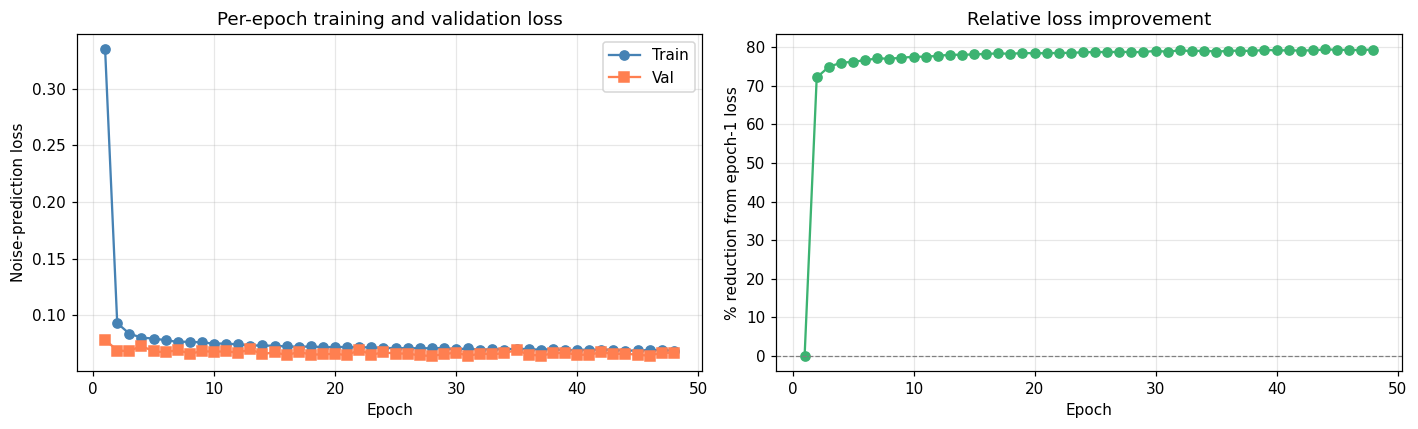

Epoch 1 loss: 0.3344
Final  loss : 0.0688  (79.4% reduction)


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(train_losses) + 1)
axes[0].plot(list(epochs), train_losses, 'o-', color='steelblue', linewidth=1.5, label='Train')
axes[0].plot(list(epochs), val_losses,   's-', color='coral',     linewidth=1.5, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Noise-prediction loss')
axes[0].set_title('Per-epoch training and validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Relative improvement curve (useful for detecting convergence)
if len(train_losses) > 1:
    rel_improvement = [(train_losses[0] - l) / train_losses[0] * 100 for l in train_losses]
    axes[1].plot(list(epochs), rel_improvement, 'o-', color='mediumseagreen', linewidth=1.5)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('% reduction from epoch-1 loss')
    axes[1].set_title('Relative loss improvement')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
print(f'Saved → {RESULTS_DIR / "loss_curves.png"}')
plt.show()
print(f'Epoch 1 loss: {train_losses[0]:.4f}')
print(f'Final  loss : {train_losses[-1]:.4f}  ({(train_losses[0]-train_losses[-1])/train_losses[0]*100:.1f}% reduction)')
if QUICK_RUN:
    print('\n⚠ QUICK_RUN=True: only 5 epochs trained. For thesis-quality results,')
    print('  set QUICK_RUN=False and run on GPU (~200 epochs, several hours).')

## 5. Quick sample inspection (DDIM 50 steps)

Saved → /content/tesina/results/diffusion/sample_inspection.png


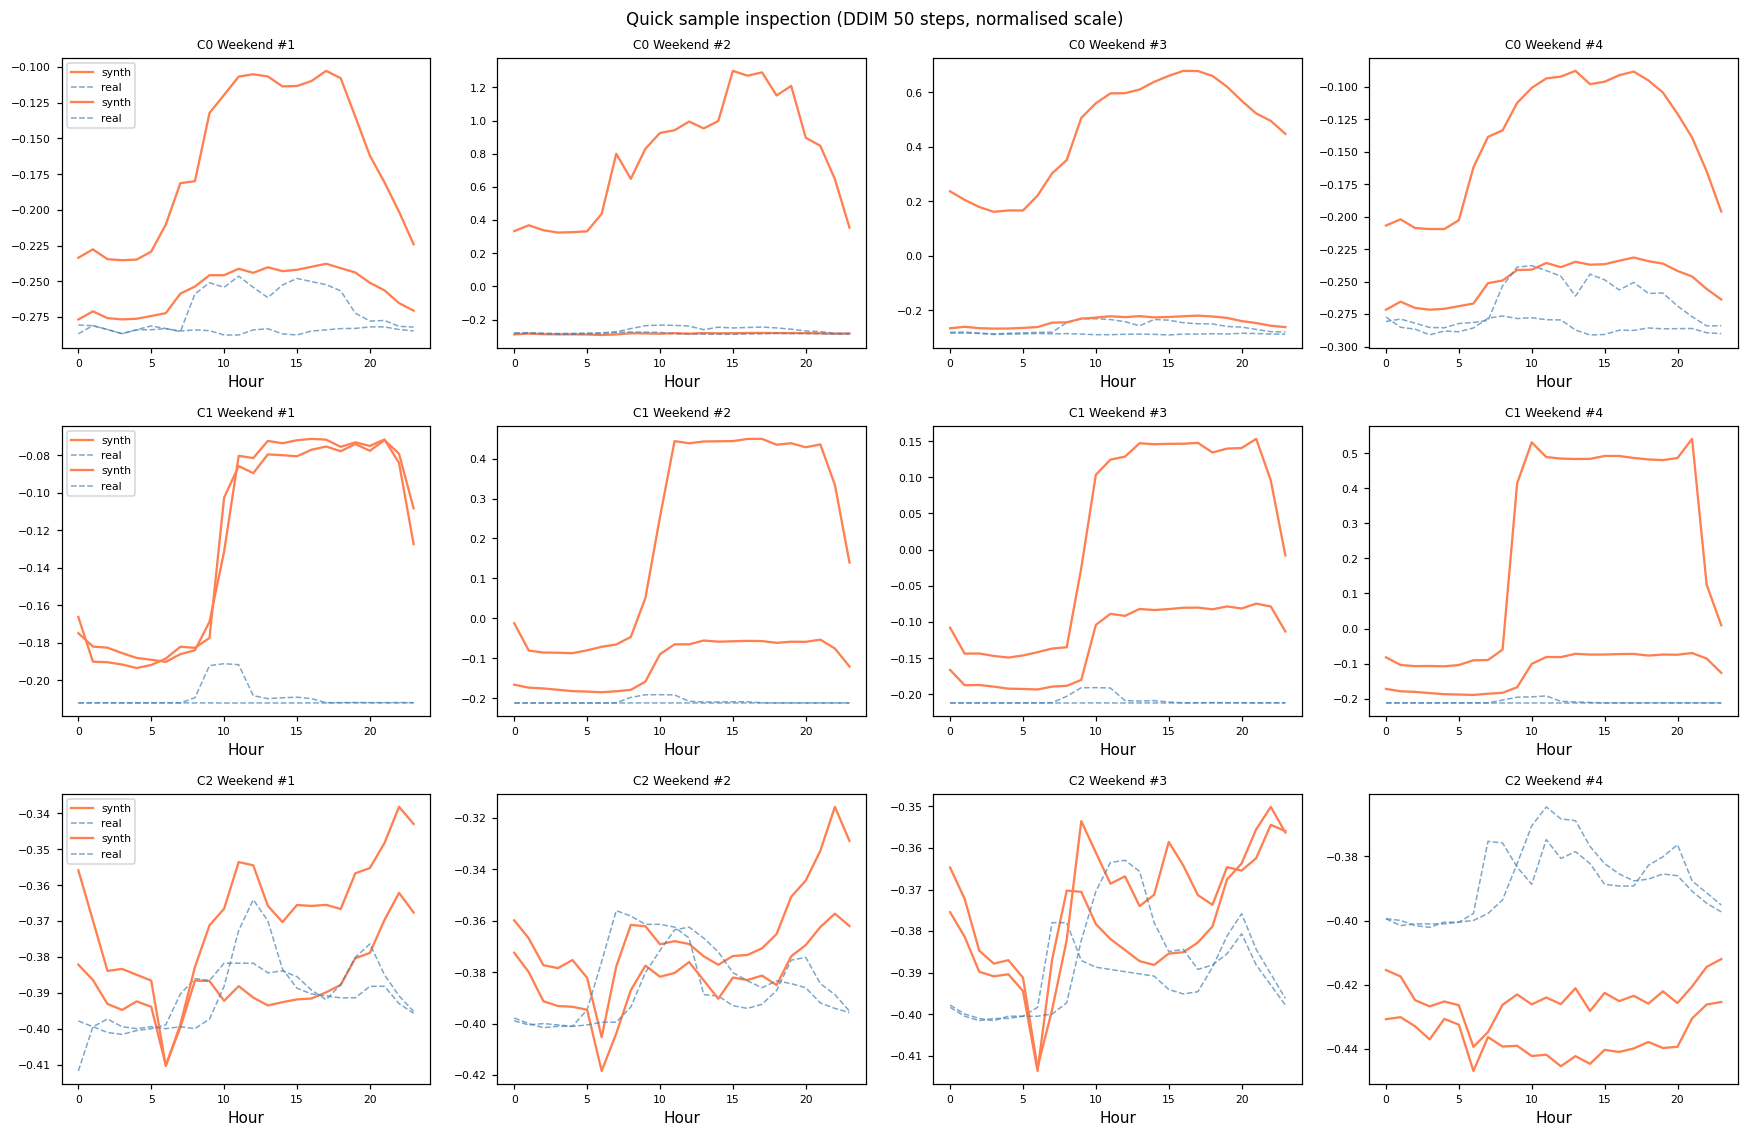

In [33]:

hours  = np.arange(24)
n_show = 4

fig, axes = plt.subplots(N_CLUSTERS, 4, figsize=(16, 3.5 * N_CLUSTERS))
day_labels = ['Weekday', 'Weekend']

for cid in range(N_CLUSTERS):
    for dt in range(2):
        # month=5 (June), dow=1 (Tue) for weekday, dow=5 (Sat) for weekend
        rep_dow = 1 if dt == 0 else 5
        c_batch  = jnp.array([[cid, dt, 5, rep_dow]] * n_show, dtype=jnp.int32)
        gen_key  = jax.random.PRNGKey(cid * 10 + dt)
        samples_norm = diffusion.ddim_sample(
            trainer.model, c_batch,
            seq_len=24, batch_size=n_show,
            key=gen_key, n_steps=50, guidance_scale=GUIDANCE_SCALE
        )  # (n_show, 24) — normalised
        samples_norm = np.array(samples_norm)

        real_mask = (c_train[:, 0] == cid) & (c_train[:, 1] == dt)
        real_sample = x_train[real_mask][:n_show] if real_mask.sum() > 0 else None

        for k in range(n_show):
            ax = axes[cid, k] if N_CLUSTERS > 1 else axes[k]
            ax.plot(hours, samples_norm[k], color='coral', linewidth=1.5, label='synth')
            if real_sample is not None and k < len(real_sample):
                ax.plot(hours, real_sample[k], color='steelblue', linewidth=1,
                        linestyle='--', alpha=0.7, label='real')
            title_sfx = day_labels[dt]
            ax.set_title(f'C{cid} {title_sfx} #{k+1}', fontsize=8)
            ax.set_xlabel('Hour'); ax.tick_params(labelsize=7)
            if k == 0: ax.legend(fontsize=7)

plt.suptitle('Quick sample inspection (DDIM 50 steps, normalised scale)', fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sample_inspection.png', dpi=150, bbox_inches='tight')
print(f'Saved → {RESULTS_DIR / "sample_inspection.png"}')
plt.show()

## 6. Save final checkpoint

In [34]:

trainer.save(CHECKPOINT_NAME)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array)))
print(f"  Parameters : {n_params:,}")
print(f"  Epochs done: {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})")
if trainer.val_losses:
    print(f"  Best val   : {min(trainer.val_losses):.4f}  (epoch {np.argmin(trainer.val_losses)+1})")


  ✓ checkpoint saved → /content/tesina/checkpoints/best_model.pkl
  Parameters : 846,338
  Epochs done: 200  (QUICK_RUN=False)
  Best val   : 0.0642  (epoch 28)


## 7. Observations


In [35]:

# ── §7 Training observations ─────────────────────────────────────────────────

print("=" * 60)
print("TRAINING RUN SUMMARY")
print("=" * 60)

print(f"\n  Epochs        : {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Learning rate : {LR}  (cosine schedule, warmup={WARMUP_STEPS})")
print(f"  Steps/epoch   : {max(1, len(x_train) // BATCH_SIZE)}")
print(f"  Model params  : {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array))):,}")

summary = {
    "epochs": N_EPOCHS,
    "quick_run": QUICK_RUN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "warmup_steps": WARMUP_STEPS,
    "guidance_scale": GUIDANCE_SCALE,
    "n_clusters": N_CLUSTERS,
    "model_params": int(sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array)))),
    "device": str(jax.devices()[0]),
    "train_losses": trainer.train_losses,
    "val_losses": trainer.val_losses,
}

if trainer.train_losses:
    first, last = trainer.train_losses[0], trainer.train_losses[-1]
    pct = (first - last) / first * 100
    print(f"\n  Initial loss  : {first:.4f}")
    print(f"  Final loss    : {last:.4f}  ({pct:.1f}% reduction)")
    best_epoch = int(np.argmin(trainer.val_losses)) + 1 if trainer.val_losses else "—"
    best_val   = min(trainer.val_losses)               if trainer.val_losses else float('nan')
    print(f"  Best val loss : {best_val:.4f}  (epoch {best_epoch})")
    summary["initial_loss"] = first
    summary["final_loss"] = last
    summary["loss_reduction_pct"] = round(pct, 2)
    summary["best_val_loss"] = best_val
    summary["best_val_epoch"] = best_epoch

print(f"\n  Training device: {jax.devices()[0]}")

# ── Save training summary to disk ───────────────────────────────────────────
summary_path = RESULTS_DIR / 'training_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n  Results saved to {RESULTS_DIR}/")
print(f"    - training_summary.json")
print(f"    - loss_curves.png")
print(f"    - sample_inspection.png")

print(f"\n  Next step: run 04_evaluation.ipynb after full training on GPU (~200 epochs).")
print("  Expected full-training metric targets:")
print("    Discriminative accuracy ≤ 0.55  (good sample quality)")
print("    ACF L2 distance         ≤ 0.05  (temporal structure preserved)")

TRAINING RUN SUMMARY

  Epochs        : 200  (QUICK_RUN=False)
  Batch size    : 256
  Learning rate : 0.002  (cosine schedule, warmup=2000)
  Steps/epoch   : 1168
  Model params  : 846,338

  Initial loss  : 0.3344
  Final loss    : 0.0688  (79.4% reduction)
  Best val loss : 0.0642  (epoch 28)

  Training device: cuda:0

  Results saved to /content/tesina/results/diffusion/
    - training_summary.json
    - loss_curves.png
    - sample_inspection.png

  Next step: run 04_evaluation.ipynb after full training on GPU (~200 epochs).
  Expected full-training metric targets:
    Discriminative accuracy ≤ 0.55  (good sample quality)
    ACF L2 distance         ≤ 0.05  (temporal structure preserved)


## 8. Inline evaluation on the active runtime

Run the baseline DDPM evaluation in the same kernel used for training so the in-memory model and Colab-side checkpoint are available without switching kernels.

In [36]:
def sample_condition_batch(condition_rows: np.ndarray, n_samples: int, seed: int | None = None) -> np.ndarray:
    rows = np.asarray(condition_rows, dtype=np.int32)
    if rows.ndim != 2 or rows.shape[1] != 4:
        raise ValueError(f'Expected conditioning array of shape (N, 4); got {rows.shape}')
    if len(rows) == 0:
        raise ValueError('Cannot sample from an empty conditioning array')
    rng = np.random.default_rng(seed)
    replace = len(rows) < n_samples
    indices = rng.choice(len(rows), size=n_samples, replace=replace)
    return rows[indices].astype(np.int32, copy=False)

def _acf(x: np.ndarray, nlags: int) -> np.ndarray:
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom == 0:
        return np.zeros(nlags + 1, dtype=np.float64)
    out = []
    for lag in range(nlags + 1):
        out.append(float(np.dot(x[: len(x) - lag], x[lag:]) / denom))
    return np.array(out, dtype=np.float64)

def acf_l2_score(real: np.ndarray, synthetic: np.ndarray, nlags: int = 23) -> float:
    nlags = min(nlags, real.shape[1] - 1)
    real_acfs = np.array([_acf(row, nlags) for row in real])
    synth_acfs = np.array([_acf(row, nlags) for row in synthetic])
    return float(np.linalg.norm(real_acfs.mean(0) - synth_acfs.mean(0)))

def crps_score_np(real: np.ndarray, samples: np.ndarray) -> float:
    n_samples = samples.shape[0]
    real_exp = real[:, None, :]
    samp_exp = samples[None, :, :]
    mae_term = np.abs(real_exp - samp_exp).mean(axis=1)
    sorted_samples = np.sort(samples, axis=0)
    ranks = (2 * np.arange(n_samples) - n_samples + 1)[:, None]
    disp_term = (ranks * sorted_samples).sum(0) / (n_samples ** 2)
    return float((mae_term - disp_term[None, :]).mean())

def discriminative_score_np(real: np.ndarray, synthetic: np.ndarray, seed: int = 0, n_steps: int = 400, lr: float = 0.1) -> float:
    n_min = min(len(real), len(synthetic))
    rng = np.random.default_rng(seed)
    real_sub = real[rng.choice(len(real), n_min, replace=False)]
    synth_sub = synthetic[rng.choice(len(synthetic), n_min, replace=False)]
    X = np.concatenate([real_sub, synth_sub], axis=0).astype(np.float64)
    y = np.concatenate([np.zeros(n_min), np.ones(n_min)], axis=0)

    perm = rng.permutation(len(X))
    X = X[perm]
    y = y[perm]

    split = max(1, int(0.8 * len(X)))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    if len(X_test) == 0:
        X_train, X_test = X[:-1], X[-1:]
        y_train, y_test = y[:-1], y[-1:]

    mean = X_train.mean(0, keepdims=True)
    std = X_train.std(0, keepdims=True) + 1e-6
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    w = np.zeros(X_train.shape[1], dtype=np.float64)
    b = 0.0

    for _ in range(n_steps):
        logits = X_train @ w + b
        probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -30.0, 30.0)))
        error = probs - y_train
        grad_w = (X_train.T @ error) / len(X_train)
        grad_b = float(error.mean())
        w -= lr * grad_w
        b -= lr * grad_b

    test_logits = X_test @ w + b
    test_probs = 1.0 / (1.0 + np.exp(-np.clip(test_logits, -30.0, 30.0)))
    preds = (test_probs >= 0.5).astype(np.float64)
    return float((preds == y_test).mean())

EVAL_RESULTS_DIR = RESULTS_DIR.parent / 'evaluation'
EVAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Evaluation dir:', EVAL_RESULTS_DIR)

Evaluation dir: /content/tesina/results/evaluation


In [37]:
EVAL_SAMPLES = 500
eval_rng = np.random.default_rng(0)

conditions_eval = [
    (cid, dt, 'weekday' if dt == 0 else 'weekend')
    for cid in range(N_CLUSTERS)
    for dt in range(2)
]

eval_results = {}

for cid, dt, day_name in conditions_eval:
    label = f'cluster{cid}_{day_name}'
    mask = (c_val[:, 0] == cid) & (c_val[:, 1] == dt)
    real_windows = x_val[mask]
    cond_rows = c_val[mask]
    if real_windows.shape[0] == 0:
        print(f'[SKIP] {label}: no validation windows')
        continue

    c_batch_np = sample_condition_batch(
        cond_rows,
        n_samples=EVAL_SAMPLES,
        seed=int(eval_rng.integers(0, 2**31)),
    )
    c_batch = jnp.array(c_batch_np, dtype=jnp.int32)
    synth = diffusion.ddim_sample(
        trainer.model, c_batch,
        seq_len=24, batch_size=EVAL_SAMPLES,
        key=jax.random.PRNGKey(cid * 100 + dt),
        n_steps=50, guidance_scale=GUIDANCE_SCALE,
    )
    synth = np.array(synth)

    eval_results[label] = {
        'real': real_windows,
        'synthetic': synth,
        'cluster': cid,
        'day_type': dt,
        'n_empirical_meta': len(np.unique(cond_rows[:, 2:], axis=0)),
    }
    print(
        f'{label}: {real_windows.shape[0]} real | {EVAL_SAMPLES} synthetic | '
        f'empirical month/dow combos={eval_results[label]["n_empirical_meta"]}'
    )

cluster0_weekday: 21924 real | 500 synthetic | empirical month/dow combos=60
cluster0_weekend: 8764 real | 500 synthetic | empirical month/dow combos=24
cluster1_weekday: 3915 real | 500 synthetic | empirical month/dow combos=60
cluster1_weekend: 1565 real | 500 synthetic | empirical month/dow combos=24
cluster2_weekday: 11745 real | 500 synthetic | empirical month/dow combos=60
cluster2_weekend: 4695 real | 500 synthetic | empirical month/dow combos=24


In [38]:
all_metric_rows = []

for label, payload in eval_results.items():
    real = payload['real']
    synthetic = payload['synthetic']
    acf_l2 = acf_l2_score(real, synthetic)
    crps = crps_score_np(real, synthetic)
    disc = discriminative_score_np(real, synthetic, seed=0)
    all_metric_rows.append({
        'condition': label,
        'acf_l2': acf_l2,
        'crps': crps,
        'discriminative_acc': disc,
        'n_empirical_meta': payload['n_empirical_meta'],
        'n_real': len(real),
        'n_synthetic': len(synthetic),
    })
    print(
        f'{label:<18s} acf_l2={acf_l2:.4f}  crps={crps:.4f}  '
        f'disc={disc:.4f}  meta={payload["n_empirical_meta"]}'
    )

metrics_df = pd.DataFrame(all_metric_rows).set_index('condition')
metrics_path = EVAL_RESULTS_DIR / 'evaluation_metrics.csv'
metrics_df.to_csv(metrics_path)

print('\nEvaluation summary:')
print(metrics_df[['acf_l2', 'crps', 'discriminative_acc', 'n_empirical_meta']].round(4).to_string())
print(f'\nSaved -> {metrics_path}')

cluster0_weekday   acf_l2=0.2168  crps=0.1130  disc=0.5950  meta=60
cluster0_weekend   acf_l2=0.2658  crps=0.1193  disc=0.6450  meta=24
cluster1_weekday   acf_l2=0.1107  crps=0.0380  disc=0.7250  meta=60
cluster1_weekend   acf_l2=0.0915  crps=0.0426  disc=0.7050  meta=24
cluster2_weekday   acf_l2=0.1929  crps=0.2194  disc=0.6000  meta=60
cluster2_weekend   acf_l2=0.3893  crps=0.2007  disc=0.6450  meta=24

Evaluation summary:
                  acf_l2    crps  discriminative_acc  n_empirical_meta
condition                                                             
cluster0_weekday  0.2168  0.1130               0.595                60
cluster0_weekend  0.2658  0.1193               0.645                24
cluster1_weekday  0.1107  0.0380               0.725                60
cluster1_weekend  0.0915  0.0426               0.705                24
cluster2_weekday  0.1929  0.2194               0.600                60
cluster2_weekend  0.3893  0.2007               0.645                24

Sa

## 9. Package artifacts for preservation

Bundle the checkpoint and generated DDPM outputs into a single archive inside the active runtime so they can be copied out before the Colab session expires.

In [42]:
import json
import os
import shutil
import tarfile
from datetime import datetime, UTC
from pathlib import Path

EXPORTS_DIR = REPO_ROOT / 'results' / 'exports'
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

DOWNLOAD_ARCHIVE_IN_COLAB = True
LOCAL_REPO_CANDIDATES = [
    Path(os.environ['TESINA_LOCAL_REPO_DIR']) if 'TESINA_LOCAL_REPO_DIR' in os.environ else None,
    Path('/home/nicola/Desktop/Supsi/tesina'),
]

timestamp = datetime.now(UTC).strftime('%Y%m%dT%H%M%SZ')
archive_path = EXPORTS_DIR / f'ddpm_baseline_{timestamp}.tar.gz'
manifest_path = EXPORTS_DIR / f'ddpm_baseline_{timestamp}.manifest.json'
restore_local_command = f'python scripts/restore_export_bundle.py results/exports/{archive_path.name}'

paths_to_bundle = [
    CHECKPOINT_DIR / CHECKPOINT_NAME,
    RESULTS_DIR / 'training_summary.json',
    RESULTS_DIR / 'loss_curves.png',
    RESULTS_DIR / 'sample_inspection.png',
    EVAL_RESULTS_DIR / 'evaluation_metrics.csv',
]

existing_paths = [path for path in paths_to_bundle if path.exists()]
missing_paths = [str(path) for path in paths_to_bundle if not path.exists()]
if not existing_paths:
    raise FileNotFoundError('No DDPM artifacts found to package.')

manifest = {
    'repo_root': str(REPO_ROOT),
    'created_utc': timestamp,
    'archive_path': str(archive_path),
    'restore_local_command': restore_local_command,
    'files': [
        {
            'path': str(path),
            'size_bytes': int(path.stat().st_size),
            'relative_to_repo': str(path.relative_to(REPO_ROOT)),
        }
        for path in existing_paths
    ],
    'missing_files': missing_paths,
}

with tarfile.open(archive_path, 'w:gz') as tar:
    for path in existing_paths:
        tar.add(path, arcname=str(path.relative_to(REPO_ROOT)))

with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

mirrored_root = None
for candidate in LOCAL_REPO_CANDIDATES:
    if candidate is None:
        continue
    candidate = candidate.expanduser()
    if not candidate.exists():
        continue
    try:
        if candidate.resolve() == REPO_ROOT.resolve():
            continue
    except FileNotFoundError:
        continue
    if not (candidate / 'data').exists():
        continue

    for path in existing_paths:
        destination = candidate / path.relative_to(REPO_ROOT)
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, destination)

    destination_archive = candidate / 'results' / 'exports' / archive_path.name
    destination_manifest = candidate / 'results' / 'exports' / manifest_path.name
    destination_archive.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive_path, destination_archive)
    shutil.copy2(manifest_path, destination_manifest)
    mirrored_root = candidate
    break

print(f'Archive  : {archive_path}')
print(f'Manifest : {manifest_path}')
for item in manifest['files']:
    print(f"  - {item['relative_to_repo']}  ({item['size_bytes'] / 1e6:.2f} MB)")
if missing_paths:
    print('Missing optional files:')
    for path in missing_paths:
        print(f'  - {path}')

print('Local restore command:')
print(f'  {restore_local_command}')

if mirrored_root is not None:
    print(f'Local mirror : {mirrored_root}')
    print('  ✓ checkpoint and result files were copied into the detected local repo tree.')
else:
    print('Local mirror : not available from this kernel.')
    print('  After downloading, place the archive under results/exports/ in the local repo and run the restore command above.')
    print('  Notebook 04 can also auto-restore the latest bundle from results/exports/.')

if _is_colab() and DOWNLOAD_ARCHIVE_IN_COLAB:
    try:
        from google.colab import files
        files.download(str(archive_path))
        files.download(str(manifest_path))
        print('Browser download triggered for the DDPM archive and manifest.')
    except Exception as exc:
        print(f'Automatic browser download failed: {exc}')

Archive  : /content/tesina/results/exports/ddpm_baseline_20260408T133417Z.tar.gz
Manifest : /content/tesina/results/exports/ddpm_baseline_20260408T133417Z.manifest.json
  - checkpoints/best_model.pkl  (10.18 MB)
  - results/diffusion/training_summary.json  (0.00 MB)
  - results/diffusion/loss_curves.png  (0.07 MB)
  - results/diffusion/sample_inspection.png  (0.41 MB)
  - results/evaluation/evaluation_metrics.csv  (0.00 MB)
Local restore command:
  python scripts/restore_export_bundle.py results/exports/ddpm_baseline_20260408T133417Z.tar.gz
Local mirror : not available from this kernel.
  After downloading, place the archive under results/exports/ in the local repo and run the restore command above.
  Notebook 04 can also auto-restore the latest bundle from results/exports/.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Browser download triggered for the DDPM archive and manifest.
